In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

data = load_breast_cancer(as_frame=True)  # dataset médico
X = data.data.copy()
y = data.target.copy()                   # 0=malignant, 1=benign (lo usaremos solo al final)
feature_names = X.columns

print(X.shape, " | clases reales:", np.bincount(y))


(569, 30)  | clases reales: [212 357]


1) Preprocesado (imprescindible)

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2) Ajuste: Aglomerativo (Ward) con k=2

In [13]:

model_ward = AgglomerativeClustering(n_clusters=2, linkage="ward", metric="euclidean")
labels_ward = model_ward.fit_predict(X_scaled)

print("Tamaños de clusters:", np.bincount(labels_ward))
print("Silhouette:", round(silhouette_score(X_scaled, labels_ward), 3))


Tamaños de clusters: [184 385]
Silhouette: 0.339


3) Visual : PCA en 2D coloreado por cluster

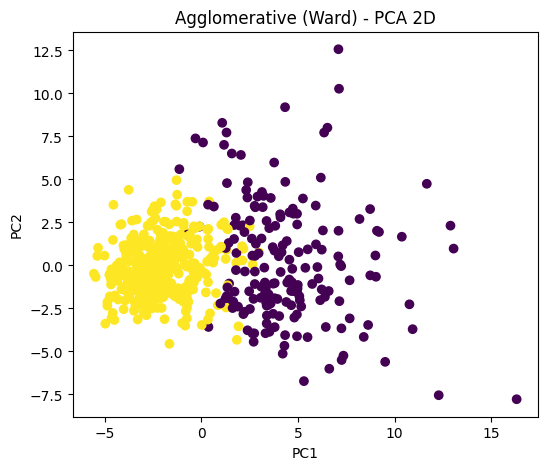

In [5]:
pca = PCA(n_components=2, random_state=0)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_ward)
plt.title("Agglomerative (Ward) - PCA 2D")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


4) Detalles: perfil del cluster (variables más distintivas)

Aquí normalmente verán que un cluster tiende a valores mayores en variables relacionadas con tamaño/forma (p.ej. radius/perimeter/area), lo cual suele alinearse bastante con maligno/benigno.

Top variables que más separan clusters:
worst area         815.104584
mean area          480.525519
area error          53.545562
worst perimeter     50.383543
mean perimeter      34.284401
worst radius         7.050187
mean radius          4.782173
worst texture        4.474658
dtype: float64


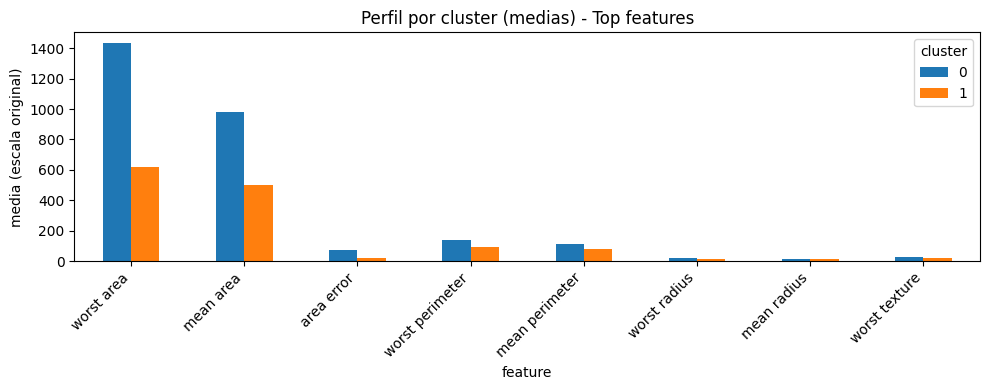

In [6]:
df = X.copy()
df["cluster"] = labels_ward

means = df.groupby("cluster").mean(numeric_only=True)
diff = (means.loc[0] - means.loc[1]).abs().sort_values(ascending=False)

top = diff.head(8).index.tolist()
print("Top variables que más separan clusters:")
print(diff.head(8))

# Plot de medias en top features
means_top = means[top].T
means_top.plot(kind="bar", figsize=(10,4))
plt.title("Perfil por cluster (medias) - Top features")
plt.xlabel("feature"); plt.ylabel("media (escala original)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [7]:
ari = adjusted_rand_score(y, labels_ward)
print("ARI vs etiqueta real:", round(ari, 3))

# Tabla cruzada cluster vs etiqueta real
ct = pd.crosstab(labels_ward, y, rownames=["cluster"], colnames=["y real (0=mal,1=ben)"])
print(ct)


ARI vs etiqueta real: 0.575
y real (0=mal,1=ben)    0    1
cluster                       
0                     164   20
1                      48  337


Dendograma

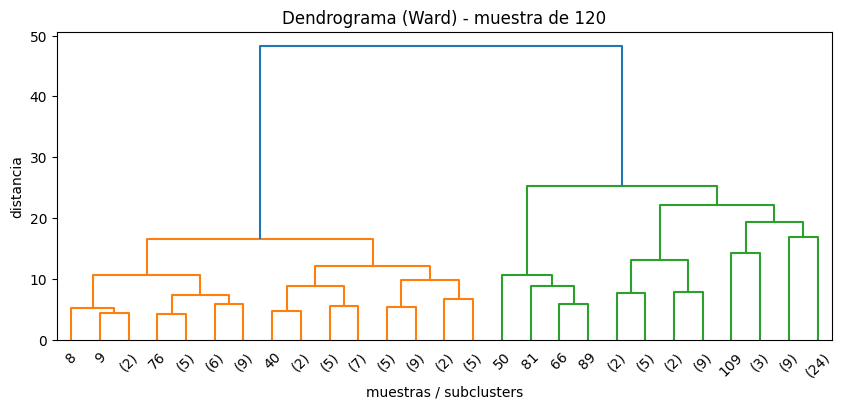

In [9]:
from scipy.cluster.hierarchy import dendrogram

# submuestra para un dendrograma que se pueda leer
np.random.seed(0)
idx = np.random.choice(len(X_scaled), size=120, replace=False)
X_small = X_scaled[idx]

# construir árbol completo: n_clusters=None + distance_threshold=0
model_tree = AgglomerativeClustering(
    n_clusters=None, distance_threshold=0,
    linkage="ward", metric="euclidean"
)
model_tree.fit(X_small)

def plot_dendrogram(model, **kwargs):
    # cuenta muestras en cada nodo
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, (left, right) in enumerate(model.children_):
        c = 0
        c += 1 if left < n_samples else counts[left - n_samples]
        c += 1 if right < n_samples else counts[right - n_samples]
        counts[i] = c

    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)

plt.figure(figsize=(10,4))
plot_dendrogram(model_tree, truncate_mode="level", p=4)  # truncado para claridad
plt.title("Dendrograma (Ward) - muestra de 120")
plt.xlabel("muestras / subclusters"); plt.ylabel("distancia")
plt.show()
